# Super Resolution SRGAN Pipeline for Remote Run
This notebook contains the complete pipeline to run Data Ingestion, Transformation, and Model Training sequentially on a remote machine like Colab.


In [30]:
import sys
!{sys.executable} -m pip install h5py lpips tqdm scikit-image opencv-python tensorboard pyyaml matplotlib datasets

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 7.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.2/625.2 kB 8.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 23.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 42.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 72.2 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 52.7 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━ 16/24 [multiprocess]  WARNING: The script markdown-it is installed in '/home/sahil3100/.local/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━ 20/24 [aiohttp]  WARNING: The script typer is installed in '/home/sahil3100/.local/bin' which is not on PATH.
  Consider a

In [18]:
!pip install h5py lpips tqdm scikit-image opencv-python tensorboard pyyaml matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [19]:
import os
import urllib.request
import zipfile
import time
from pathlib import Path
from tqdm import tqdm
import cv2
import h5py
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset
from torch.utils.tensorboard import SummaryWriter
from skimage.metrics import peak_signal_noise_ratio as psnr_func
from skimage.metrics import structural_similarity as ssim_func
import lpips
import logging

logging.basicConfig(level=logging.INFO, format="[%(asctime)s] %(levelname)s: %(message)s")
logger = logging.getLogger("remote_training")


In [ ]:
from dataclasses import dataclass

@dataclass
class DataIngestionConfig:
    root_dir: Path
    dataset_name: str
    dataset_root: Path
    train_hr_dir: Path
    train_lr_dir: Path
    val_hr_dir: Path
    val_lr_dir: Path
    test_dataset_name: str
    test_dataset_root: Path
    test_hr_dir: Path
    test_lr_dir: Path
    download_enabled: bool
    download_urls: dict
    processing_scale: int
    processing_patch_size: int
    processing_batch_size: int
    processing_num_workers: int

@dataclass
class DataTransformationConfig:
    root_dir: Path
    data_path: Path
    srcnn_dir: Path
    srgan_dir: Path
    patch_size: int
    stride: int
    scale: int

@dataclass
class ModelTrainingConfig:
    root_dir: Path
    train_data_path: Path
    valid_data_path: Path
    model_path: Path
    model_type: str
    epochs: int
    batch_size: int
    learning_rate: float
    normalization: str
    device: str
    patience: int
    log_step: int

# Configuration Instances
ingestion_config = DataIngestionConfig(
    root_dir=Path("data/raw"),
    dataset_name="DIV2K",
    dataset_root=Path("data/raw/DIV2K"),
    train_hr_dir=Path("data/raw/DIV2K/DIV2K_train_HR"),
    train_lr_dir=Path("data/raw/DIV2K/DIV2K_train_LR_bicubic/X4"),
    val_hr_dir=Path("data/raw/DIV2K/DIV2K_valid_HR"),
    val_lr_dir=Path("data/raw/DIV2K/DIV2K_valid_LR_bicubic/X4"),
    test_dataset_name="Set5",
    test_dataset_root=Path("data/raw/Set5"),
    test_hr_dir=Path("data/raw/Set5/set5"),
    test_lr_dir=Path("data/raw/Set5/set5"),
    download_enabled=True,
    download_urls={
        "train_hr": "https://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_train_HR.zip",
        "train_lr_x4": "https://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_train_LR_bicubic_X4.zip",
        "val_hr": "https://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_valid_HR.zip",
        "val_lr_x4": "https://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_valid_LR_bicubic_X4.zip",
        "set5": "https://data.deepai.org/set5.zip"
    },
    processing_scale=4,
    processing_patch_size=96,
    processing_batch_size=16,
    processing_num_workers=4
)

transformation_config = DataTransformationConfig(
    root_dir=Path("data/processed"),
    data_path=Path("data/raw/DIV2K"),
    srcnn_dir=Path("data/processed/srcnn"),
    srgan_dir=Path("data/processed/srgan"),
    patch_size=96,
    stride=96,
    scale=4
)

training_config = ModelTrainingConfig(
    root_dir=Path("artifacts/model_training"),
    train_data_path=Path("data/processed/srcnn/srcnn_train.h5"),
    valid_data_path=Path("data/processed/srcnn/srcnn_valid.h5"),
    model_path=Path("artifacts/model_training/srcnn.pth"),
    model_type="srcnn",
    epochs=100,
    batch_size=256,
    learning_rate=0.0001,
    normalization="zero_to_one",
    device="cuda",
    patience=7,
    log_step=100
)

# Create mandatory directories immediately
for d in [ingestion_config.root_dir, transformation_config.root_dir, training_config.root_dir]:
    os.makedirs(d, exist_ok=True)


In [21]:
class DataIngestion:
    def __init__(self, config: DataIngestionConfig):
        self.config = config

    def download_file(self):
        start_time = time.time()
        for name, url in self.config.download_urls.items():
            zip_path = Path(self.config.root_dir) / f"{name}.zip"
            extract_to = self.config.test_dataset_root if name == "set5" else self.config.dataset_root
            
            if name == "set5": check_dir = self.config.test_hr_dir
            elif name == "train_hr": check_dir = self.config.train_hr_dir
            elif name == "train_lr_x4": check_dir = self.config.train_lr_dir
            elif name == "val_hr": check_dir = self.config.val_hr_dir
            elif name == "val_lr_x4": check_dir = self.config.val_lr_dir
            else: check_dir = self.config.train_hr_dir
            if check_dir.exists() and any(check_dir.iterdir()):
                logger.info(f"Skipping {name}: Data already exists.")
                continue

            try:
                os.makedirs(extract_to, exist_ok=True)
                self._download_with_progress(url, zip_path, name)
                self._perform_extraction(zip_path, extract_to)
                logger.info(f"Successfully processed {name}")
            except Exception as e:
                logger.error(f"Error processing {name}: {e}")
                if zip_path.exists(): os.remove(zip_path)

        logger.info(f"Ingestion finished in {time.time() - start_time:.2f}s")

    def _perform_extraction(self, zip_path: Path, extract_to: Path):
        logger.info(f"Extracting {zip_path.name}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_to)
        if zip_path.exists(): os.remove(zip_path)

        for root, dirs, files in os.walk(extract_to):
            for file in files:
                file_path = Path(root) / file
                if file.endswith('.zip'):
                    logger.info(f"Found nested zip: {file}. Extracting...")
                    with zipfile.ZipFile(file_path, 'r') as nested_ref:
                        nested_ref.extractall(root)
                    os.remove(file_path)
                elif file.endswith('.url') or 'Startcrack' in file:
                    os.remove(file_path)

    def _download_with_progress(self, url: str, filepath: Path, name: str):
        headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}
        request = urllib.request.Request(url, headers=headers)
        with tqdm(unit='B', unit_scale=True, unit_divisor=1024, miniters=1, desc=f"Downloading {name}") as t:
            with urllib.request.urlopen(request) as response, open(filepath, 'wb') as out_file:
                tsize = int(response.info().get('Content-Length', 0))
                t.total = tsize
                bsize = 1024 * 8
                while True:
                    block = response.read(bsize)
                    if not block: break
                    out_file.write(block)
                    t.update(len(block))


In [22]:
class DataTransformation:
    def __init__(self, config):
        self.config = config

    def create_srcnn_data(self, split='train'):
        hr_path = os.path.join(self.config.data_path, f"DIV2K_{split}_HR")
        lr_path = os.path.join(self.config.data_path, f"DIV2K_{split}_LR_bicubic", "X4")
        
        save_path = Path(self.config.srcnn_dir) / f"srcnn_{split}.h5"
        save_path.parent.mkdir(parents=True, exist_ok=True)

        with h5py.File(save_path, 'w') as h5_file:
            lr_ds = h5_file.create_dataset("lr", shape=(0, self.config.patch_size, self.config.patch_size, 3), 
                                          maxshape=(None, self.config.patch_size, self.config.patch_size, 3),
                                          dtype='uint8', chunks=True)
            hr_ds = h5_file.create_dataset("hr", shape=(0, self.config.patch_size, self.config.patch_size, 3), 
                                          maxshape=(None, self.config.patch_size, self.config.patch_size, 3),
                                          dtype='uint8', chunks=True)

            img_list = os.listdir(hr_path)
            total_patches = 0

            for i, img_name in enumerate(img_list):
                hr_img = cv2.imread(os.path.join(hr_path, img_name))
                lr_img = cv2.imread(os.path.join(lr_path, img_name.replace(".png", "x4.png")))
                
                # Check if image was correctly read
                if hr_img is None or lr_img is None: continue

                lr_upscaled = cv2.resize(lr_img, (hr_img.shape[1], hr_img.shape[0]), interpolation=cv2.INTER_CUBIC)
                current_img_patches_lr = []
                current_img_patches_hr = []

                for y in range(0, hr_img.shape[0] - self.config.patch_size + 1, self.config.stride):
                    for x in range(0, hr_img.shape[1] - self.config.patch_size + 1, self.config.stride):
                        current_img_patches_hr.append(hr_img[y:y+self.config.patch_size, x:x+self.config.patch_size])
                        current_img_patches_lr.append(lr_upscaled[y:y+self.config.patch_size, x:x+self.config.patch_size])

                if current_img_patches_hr:
                    num_new_patches = len(current_img_patches_hr)
                    lr_ds.resize(total_patches + num_new_patches, axis=0)
                    hr_ds.resize(total_patches + num_new_patches, axis=0)
                    lr_ds[total_patches:] = np.array(current_img_patches_lr)
                    hr_ds[total_patches:] = np.array(current_img_patches_hr)
                    total_patches += num_new_patches

                if i % 10 == 0:
                    logger.info(f"Processed {i}/{len(img_list)} images. Total patches: {total_patches}")

        logger.info(f"Final dataset saved. Total patches: {total_patches}")


In [23]:
class SRCNN(nn.Module):
    def __init__(self, num_channels=3):
        super(SRCNN, self).__init__()
        self.conv1 = nn.Conv2d(num_channels, 64, kernel_size=9, padding=9 // 2)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(64, 32, kernel_size=5, padding=5 // 2)
        self.relu2 = nn.ReLU(inplace=True)
        self.conv3 = nn.Conv2d(32, num_channels, kernel_size=5, padding=5 // 2)

    def forward(self, x):
        x = self.relu1(self.conv1(x))
        x = self.relu2(self.conv2(x))
        return self.conv3(x)

class HDF5Dataset(Dataset):
    def __init__(self, h5_file, normalization='zero_to_one'):
        super(HDF5Dataset, self).__init__()
        self.h5_file = h5_file
        self.norm = normalization

    def __getitem__(self, index):
        with h5py.File(self.h5_file, 'r') as f:
            lr = np.array(f['lr'][index]).astype(np.float32)
            hr = np.array(f['hr'][index]).astype(np.float32)
            if self.norm == "zero_to_one":
                lr /= 255.0; hr /= 255.0
            else:
                lr = (lr / 127.5) - 1.0; hr = (hr / 127.5) - 1.0
            return torch.from_numpy(lr).permute(2, 0, 1), torch.from_numpy(hr).permute(2, 0, 1)

    def __len__(self):
        with h5py.File(self.h5_file, 'r') as f:
            return len(f['lr'])

def calculate_psnr(img1, img2):
    return psnr_func(img1, img2, data_range=img2.max() - img2.min())

class EarlyStopping:
    def __init__(self, patience=7, min_delta=0):
        self.patience = patience; self.min_delta = min_delta; self.counter = 0; self.best_loss = None; self.early_stop = False
    def __call__(self, val_loss):
        if self.best_loss is None: self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience: self.early_stop = True
        else: self.best_loss = val_loss; self.counter = 0


In [24]:
class ModelTraining:
    def __init__(self, config: ModelTrainingConfig):
        self.config = config
        self.device = torch.device(config.device if torch.cuda.is_available() else "cpu")
        log_dir = self.config.root_dir / "logs"
        self.writer = SummaryWriter(log_dir=str(log_dir))
        if torch.cuda.is_available():
            self.scaler = torch.amp.GradScaler('cuda') 
        else:
            self.scaler = None

    def train(self):
        train_loader = self._get_dataloader(self.config.train_data_path)
        valid_loader = self._get_dataloader(self.config.valid_data_path)

        model = SRCNN().to(self.device)
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=self.config.learning_rate)
        
        early_stopping = EarlyStopping(patience=self.config.patience)
        
        # Default start values
        best_psnr = 0.0
        global_step = 0
        start_epoch = 0

        # Load Checkpoint for True Resume
        if os.path.exists(self.config.model_path):
            logger.info(f"Loading checkpoint from {self.config.model_path}")
            checkpoint = torch.load(self.config.model_path, map_location=self.device, weights_only=False)
            #checkpoint = torch.load(self.config.model_path, map_location=self.device)
            if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
                model.load_state_dict(checkpoint['model_state_dict'])
                optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
                start_epoch = checkpoint['epoch'] + 1
                best_psnr = checkpoint['best_psnr']
                global_step = checkpoint['global_step']
                logger.info(f"Resuming training from epoch {start_epoch+1} with Best PSNR: {best_psnr:.2f}dB")
            else:
                # Fallback in case it's an old save format (just weights)
                model.load_state_dict(checkpoint)
                logger.info("Loaded legacy weights only. Starting from epoch 1.")

        for epoch in range(start_epoch, self.config.epochs):
            model.train()
            epoch_loss = 0.0
            progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{self.config.epochs}")
            
            for batch_idx, (lr, hr) in enumerate(progress_bar):
                lr, hr = lr.to(self.device), hr.to(self.device)
                optimizer.zero_grad()
                
                if self.scaler:
                    with torch.amp.autocast('cuda'):
                        outputs = model(lr)
                        loss = criterion(outputs, hr)
                    self.scaler.scale(loss).backward()
                    self.scaler.step(optimizer)
                    self.scaler.update()
                else:
                    outputs = model(lr)
                    loss = criterion(outputs, hr)
                    loss.backward()
                    optimizer.step()

                epoch_loss += loss.item()
                global_step += 1

                if global_step % self.config.log_step == 0:
                    avg_step_loss = epoch_loss / (batch_idx + 1)
                    self.writer.add_scalar("Loss/Train_Step", avg_step_loss, global_step)
                    progress_bar.set_postfix({"loss": f"{avg_step_loss:.5f}"})

            avg_val_loss, avg_psnr = self._validate(model, valid_loader, criterion)
            self.writer.add_scalar("Loss/Validation", avg_val_loss, epoch)
            self.writer.add_scalar("Metrics/PSNR_dB", avg_psnr, epoch)
            logger.info(f"Epoch {epoch+1}: Val Loss: {avg_val_loss:.6f} | Val PSNR: {avg_psnr:.2f}dB")

            if avg_psnr > best_psnr:
                best_psnr = avg_psnr
                # Save Full Checkpoint instead of just weights
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'best_psnr': best_psnr,
                    'global_step': global_step
                }, self.config.model_path)
                logger.info(f"New Best Model Checkpoint saved at {best_psnr:.2f}dB PSNR")

            early_stopping(avg_val_loss)
            if early_stopping.early_stop:
                logger.warning(f"Early Stopping triggered at epoch {epoch+1}")
                break

        self.writer.close()
        logger.info("Training process finalized.")

    def _validate(self, model, loader, criterion):
        model.eval(); val_loss = 0.0; psnr_values = []
        with torch.no_grad():
            for lr, hr in loader:
                lr, hr = lr.to(self.device), hr.to(self.device)
                if self.scaler:
                    with torch.amp.autocast('cuda'):
                        outputs = model(lr)
                        loss = criterion(outputs, hr)
                else:
                    outputs = model(lr)
                    loss = criterion(outputs, hr)
                val_loss += loss.item()
                out_np = outputs.cpu().numpy() * 255.0
                hr_np = hr.cpu().numpy() * 255.0
                psnr_values.append(calculate_psnr(out_np, hr_np))
        return val_loss / len(loader), np.mean(psnr_values)

    def _get_dataloader(self, path):
        dataset = HDF5Dataset(path, normalization=self.config.normalization)
        return DataLoader(
            dataset, batch_size=self.config.batch_size, shuffle=True, 
            pin_memory=True, num_workers=2, persistent_workers=True
        )


In [25]:
# Execute Data Ingestion
logger.info("--- Starting Data Ingestion ---")
di = DataIngestion(ingestion_config)
di.download_file()


[2026-03-26 12:58:38,205] INFO: --- Starting Data Ingestion ---
[2026-03-26 12:58:38,207] INFO: Skipping train_hr: Data already exists.
[2026-03-26 12:58:38,209] INFO: Skipping train_lr_x4: Data already exists.
[2026-03-26 12:58:38,211] INFO: Skipping val_hr: Data already exists.
[2026-03-26 12:58:38,212] INFO: Skipping val_lr_x4: Data already exists.
[2026-03-26 12:59:57,613] INFO: Extracting set5.zip...
[2026-03-26 12:59:58,188] INFO: Found nested zip: SR_training_datasets.zip. Extracting...
[2026-03-26 12:59:59,173] INFO: Found nested zip: SR_testing_datasets.zip. Extracting...
[2026-03-26 13:00:02,233] INFO: Found nested zip: train_hr.zip. Extracting...
[2026-03-26 13:00:02,234] ERROR: Error processing set5: File is not a zip file
[2026-03-26 13:00:02,235] INFO: Ingestion finished in 84.03s


In [26]:
# Execute Data Transformation
logger.info("--- Starting Data Transformation ---")
dt = DataTransformation(transformation_config)

if not os.path.exists(transformation_config.srcnn_dir / "srcnn_train.h5"):
    logger.info("Creating Train HR/LR patches...")
    dt.create_srcnn_data('train')
else:
    logger.info("Train HDF5 already exists. Skipping patch creation.")

if not os.path.exists(transformation_config.srcnn_dir / "srcnn_valid.h5"):
    logger.info("Creating Valid HR/LR patches...")
    dt.create_srcnn_data('valid')
else:
    logger.info("Valid HDF5 already exists. Skipping patch creation.")


[2026-03-26 13:00:02,250] INFO: --- Starting Data Transformation ---
[2026-03-26 13:00:02,252] INFO: Train HDF5 already exists. Skipping patch creation.
[2026-03-26 13:00:02,253] INFO: Valid HDF5 already exists. Skipping patch creation.


In [ ]:
# Execute Training
# To visualize in tensorboard in Colab, run this command in a separate cell before training:
# %load_ext tensorboard
# %tensorboard --logdir artifacts/model_training/logs

logger.info("--- Starting Model Training ---")

mt = ModelTraining(training_config)
mt.train()


[2026-03-26 13:09:21,655] INFO: --- Starting Model Training ---
[2026-03-26 13:09:21,670] INFO: Loading checkpoint from artifacts/model_training/srcnn.pth
[2026-03-26 13:09:21,680] INFO: Resuming training from epoch 16 with Best PSNR: 26.29dB
Epoch 16/100:  67%|██████▋   | 9808/14739 [03:52<01:53, 43.46it/s, loss=0.00262]

[2026-03-26 13:09:09,671] INFO: --- Starting Inference from Local Folder ---
[2026-03-26 13:09:09,699] INFO: Model weights loaded successfully.
[2026-03-26 13:09:09,705] INFO: Testing on image: 101087.png (Found precisely at: data/raw/Set5/set5/BSDS100/101087.png)


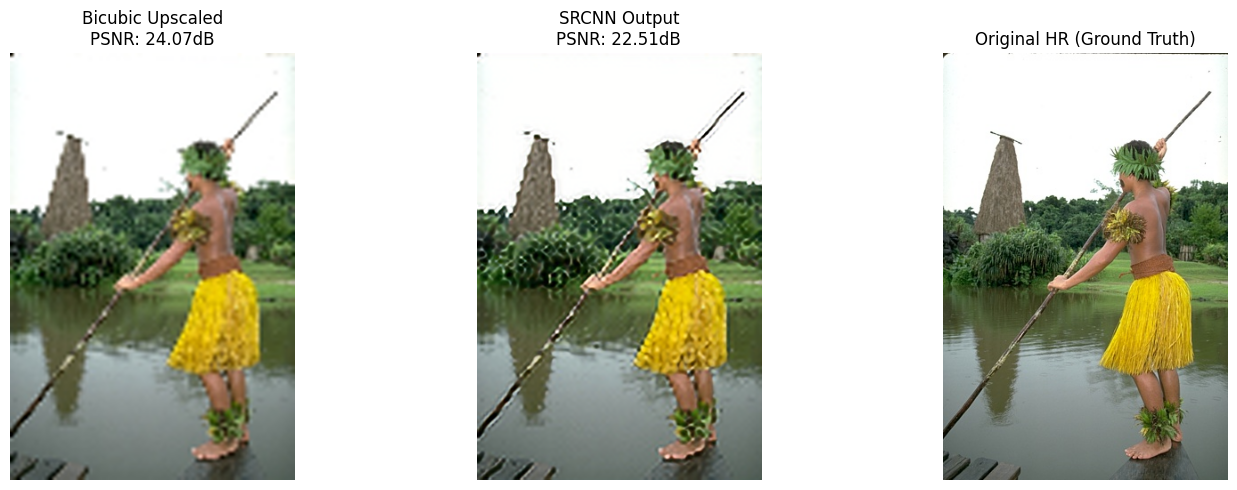

In [35]:
# INFERENCING BLOCK (FOOLPROOF PATH SEARCH)
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from skimage.metrics import peak_signal_noise_ratio as psnr_func

def run_inference(image_index=0):
    logger.info("--- Starting Inference from Local Folder ---")
    model = SRCNN().to(training_config.device)
    
    # Load model weights
    if os.path.exists(training_config.model_path):
        checkpoint = torch.load(training_config.model_path, map_location=training_config.device, weights_only=False)
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            model.load_state_dict(checkpoint['model_state_dict'])
        else:
            model.load_state_dict(checkpoint)
        logger.info("Model weights loaded successfully.")
    else:
        logger.error("Model weights not found! Train the model first.")
        return
        
    model.eval()
    
    # ----------------------------------------------------
    # DYNAMIC SEARCH FOR IMAGES (Ignores folder structure)
    # ----------------------------------------------------
    base_dir = Path("data/raw/Set5")
        
    if not base_dir.exists():
        logger.error(f"{base_dir} not found. Please ensure Data Ingestion downloaded it.")
        return
        
    # Recursively hunt down every single .png image inside the base_dir
    img_paths = sorted(list(base_dir.rglob("*.png")))
    
    if not img_paths:
        logger.error(f"No PNG images found ANYWHERE inside {base_dir}! The ZIP extraction might have failed or data was deleted.")
        return
        
    if image_index >= len(img_paths):
        logger.error(f"Image index {image_index} out of bounds. Only {len(img_paths)} images found.")
        return
        
    img_path = img_paths[image_index]
    logger.info(f"Testing on image: {img_path.name} (Found precisely at: {img_path})")
    
    # Load HR image using the exact path we discovered
    hr_img = cv2.imread(str(img_path))
    hr_img = cv2.cvtColor(hr_img, cv2.COLOR_BGR2RGB)
    
    # DeepAI only gave us HR images. Shrink dynamically to simulate missing LR image.
    scale = 4
    h, w, _ = hr_img.shape
    hr_img = hr_img[:h-(h%scale), :w-(w%scale), :] # Crop to be perfectly divisible by 4
    h, w, _ = hr_img.shape
    
    # Shrink to simulate the missing LR image
    lr_shrunk = cv2.resize(hr_img, (w // scale, h // scale), interpolation=cv2.INTER_CUBIC)
    
    # Upscale LR using bicubic to prepare for the model
    lr_upscaled = cv2.resize(lr_shrunk, (w, h), interpolation=cv2.INTER_CUBIC)
    
    # Prepare tensor
    input_tensor = lr_upscaled.astype(np.float32)
    if training_config.normalization == "zero_to_one":
        input_tensor /= 255.0
    else:
        input_tensor = (input_tensor / 127.5) - 1.0
        
    input_tensor = torch.from_numpy(input_tensor).permute(2, 0, 1).unsqueeze(0).to(training_config.device)
    
    # Infer
    with torch.no_grad():
        output_tensor = model(input_tensor)
        
    # Post-process
    output_tensor = output_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()
    if training_config.normalization == "zero_to_one":
        output_tensor *= 255.0
    else:
        output_tensor = (output_tensor + 1.0) * 127.5
        
    output_img = np.clip(output_tensor, 0, 255).astype(np.uint8)
    
    # Calculate metrics
    psnr_bicubic = psnr_func(hr_img, lr_upscaled, data_range=255)
    psnr_srcnn = psnr_func(hr_img, output_img, data_range=255)
    
    # Display
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(lr_upscaled)
    plt.title(f"Bicubic Upscaled\nPSNR: {psnr_bicubic:.2f}dB")
    plt.axis("off")
    
    plt.subplot(1, 3, 2)
    plt.imshow(output_img)
    plt.title(f"SRCNN Output\nPSNR: {psnr_srcnn:.2f}dB")
    plt.axis("off")
    
    plt.subplot(1, 3, 3)
    plt.imshow(hr_img)
    plt.title("Original HR (Ground Truth)")
    plt.axis("off")
    
    plt.tight_layout()
    plt.show()

# Run inference on the first image found
run_inference(1)
